# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [459]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read data

In [460]:
job_pools = ["coal", "brown_techchange", "brown"]

In [461]:
# names
folder_name = "reskilling_final_thresh-{threshold}"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_2019"

# model setting combinations
# low (where does number come from?), percentile (q=0.96) and empirical (mean-sd at ISCO 4-digit) thresholds for transition viability
thresholds = ["low"]  # ["low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"]
reskilling_modes = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

# iterate across all options
data_store = {}
for threshold in thresholds:
    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

## Preprocessing

threshold - reskilling - regional constraint

In [462]:
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "reskilling_mode": "first",
    "viability_threshold": "first",
    "regional_constraint": "first",
    "job_pool": "first",
}

In [463]:
job_pool = "coal"
keep_vars = [
    "n_viable_transitions",
    "earnings_delta_closest_switch_sum_mio",
    "NUTS_ID",
    "NACE1D",
    "COUNTRYW",
]

data_transformed = []
for model_version in list(data_store.keys()):
    # threshold - reskilling - regional constraint
    sub_dict = data_store[model_version]

    for job_pool in job_pools:
        # pool - country - DATA
        df_pool = pd.concat(list(sub_dict[job_pool].values()))

        # only keep select variables
        df_pool_sel = df_pool.loc[:, keep_vars]

        # add metadata of model run
        df_pool_sel["job_pool"] = job_pool
        df_pool_sel["viability_threshold"] = model_version[0]
        df_pool_sel["reskilling_mode"] = model_version[1]
        df_pool_sel["regional_constraint"] = model_version[2]

        # aggregate to regional level
        aggby = ["COUNTRYW", "NUTS_ID"]
        df_pool_sel = df_pool_sel.groupby(aggby).agg(aggdict)

        # append
        data_transformed.append(df_pool_sel)

# to df
df_final = pd.concat(data_transformed)

In [464]:
df_final["n_viable_transitions"] = df_final["n_viable_transitions"].astype(float)
df_final["earnings_delta_closest_switch_sum_mio"] = df_final[
    "earnings_delta_closest_switch_sum_mio"
].astype(float)

In [465]:
df_final = df_final.replace(
    {"job_pool": {"coal": "CPO", "brown_techchange": "FFPOTC", "brown": "FFPO"}}
)

In [466]:
df_final = df_final.reset_index()

In [467]:
earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"]
df_final.loc[
    df_final["COUNTRYW"].isin(earnings_data_missing),
    "earnings_delta_closest_switch_sum_mio",
] = np.nan
df_final

,COUNTRYW,NUTS_ID,n_viable_transitions,earnings_delta_closest_switch_sum_mio,reskilling_mode,viability_threshold,regional_constraint,job_pool
0,AT,AT11,4.00,NaN,baseline,low,regC,CPO
1,AT,AT12,0.00,NaN,baseline,low,regC,CPO
2,AT,AT13,2.50,NaN,baseline,low,regC,CPO
3,AT,AT21,2.00,NaN,baseline,low,regC,CPO
4,AT,AT22,2.80,NaN,baseline,low,regC,CPO
...,...,...,...,...,...,...,...,...
6285,UK,UKJ0,4.96,NaN,reskill-optimal,low,no-regC,FFPO
6286,UK,UKK0,4.64,NaN,reskill-optimal,low,no-regC,FFPO
6287,UK,UKL0,4.85,NaN,reskill-optimal,low,no-regC,FFPO
6288,UK,UKM0,4.59,NaN,reskill-optimal,low,no-regC,FFPO


## Visualisation

In [468]:
from statannotations.Annotator import Annotator

pairs = [
    # with regional constraints
    (("regC", "baseline"), ("regC", "reskill-optimal")),
    (("regC", "baseline"), ("regC", "reskill-random")),
    (("regC", "baseline"), ("regC", "reskill-coreWeight")),
    (("regC", "baseline"), ("regC", "reskill-digital")),
    # w/o regional constraints
    (("no-regC", "baseline"), ("no-regC", "reskill-optimal")),
    (("no-regC", "baseline"), ("no-regC", "reskill-random")),
    (("no-regC", "baseline"), ("no-regC", "reskill-coreWeight")),
    (("no-regC", "baseline"), ("no-regC", "reskill-digital")),
]

# annotate stats
pairs_regional_hue = [
    # with regional constraints
    (("baseline", "regC"), ("baseline", "no-regC")),
    (("reskill-random", "regC"), ("reskill-random", "no-regC")),
    (("reskill-coreWeight", "regC"), ("reskill-coreWeight", "no-regC")),
    (("reskill-digital", "regC"), ("reskill-digital", "no-regC")),
    (("reskill-optimal", "regC"), ("reskill-optimal", "no-regC")),
    # w/o regional constraints
]

##### Statannotations parameters

In [469]:
alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "simple"
loc = "inside"
show_test_name = False
verbose = False
palette = "BrBG"

In [470]:
# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df_final_by_country = (
    df_final.groupby(["job_pool", "reskilling_mode", "regional_constraint", "COUNTRYW"])
    .agg(aggdict)
    .reset_index()
)

##### Transition numbers

Boxplot

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


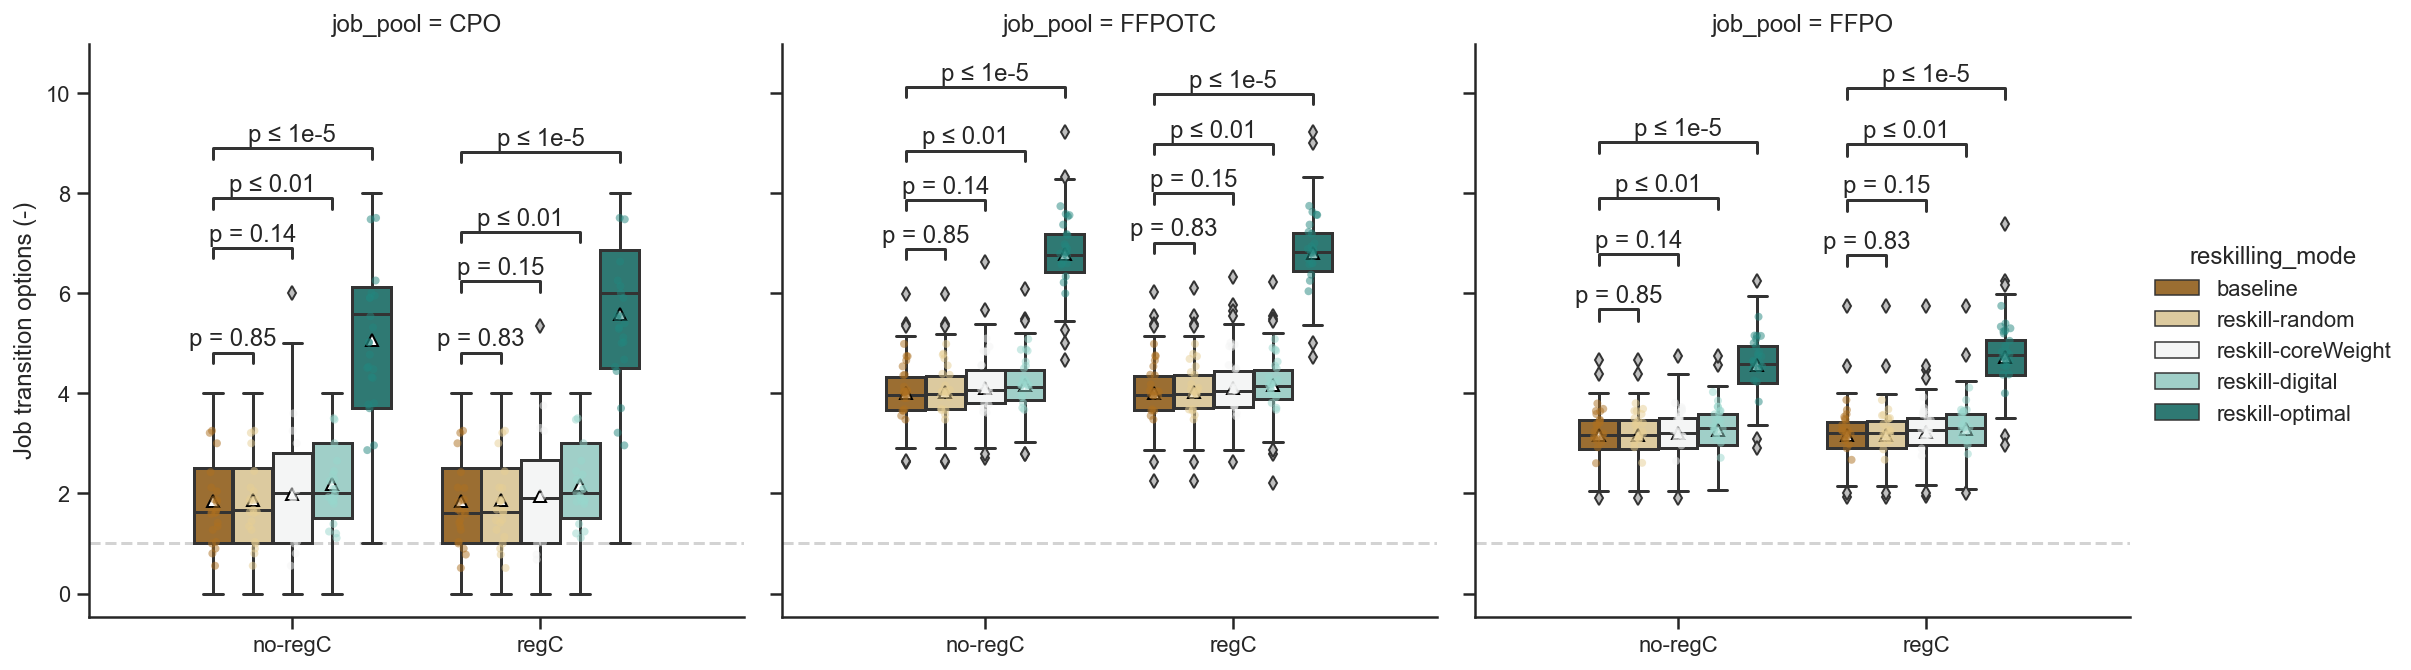

In [471]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    "reskill-optimal",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # country-level stripplot
    sns.stripplot(
        x=x,
        y=y,
        data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]],
        order=order,
        hue_order=hue_order,
        hue=hue,
        dodge=True,
        marker="o",
        size=4,
        edgecolor="black",
        palette=palette,
        alpha=0.5,
        ax=ax,
    )
    ax.legend([], [], frameon=False)

    # # country-level scatterplot
    # sns.scatterplot(
    #     x=hue,
    #     y=y,
    #     data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]].dropna(subset=["COUNTRYW"]),
    #     style="COUNTRYW",
    #     hue="COUNTRYW",
    #     marker='o',
    #     size=4,
    #     edgecolor="black",
    #     palette="Paired",
    #     alpha=0.5,
    #     ax=ax,
    # )

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax,
        pairs,
        data=df_final,
        x=x,
        y=y,
        order=order,
        hue=hue,
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [472]:
df_final_by_country.query(
    "(job_pool=='CPO') & (reskilling_mode=='baseline') & (regional_constraint=='no-regC')"
)

,job_pool,reskilling_mode,regional_constraint,COUNTRYW,n_viable_transitions,earnings_delta_closest_switch_sum_mio,viability_threshold
0,CPO,baseline,no-regC,AT,1.88,0.00,low
1,CPO,baseline,no-regC,BE,3.25,-21.47,low
2,CPO,baseline,no-regC,CH,3.21,-38.41,low
3,CPO,baseline,no-regC,CZ,1.63,0.00,low
4,CPO,baseline,no-regC,DE,2.42,-780.54,low
5,CPO,baseline,no-regC,DK,1.59,-31.06,low
6,CPO,baseline,no-regC,ES,1.61,0.00,low
7,CPO,baseline,no-regC,FI,0.80,-45.62,low
8,CPO,baseline,no-regC,FR,1.82,-797.43,low
9,CPO,baseline,no-regC,GR,2.04,0.00,low


C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


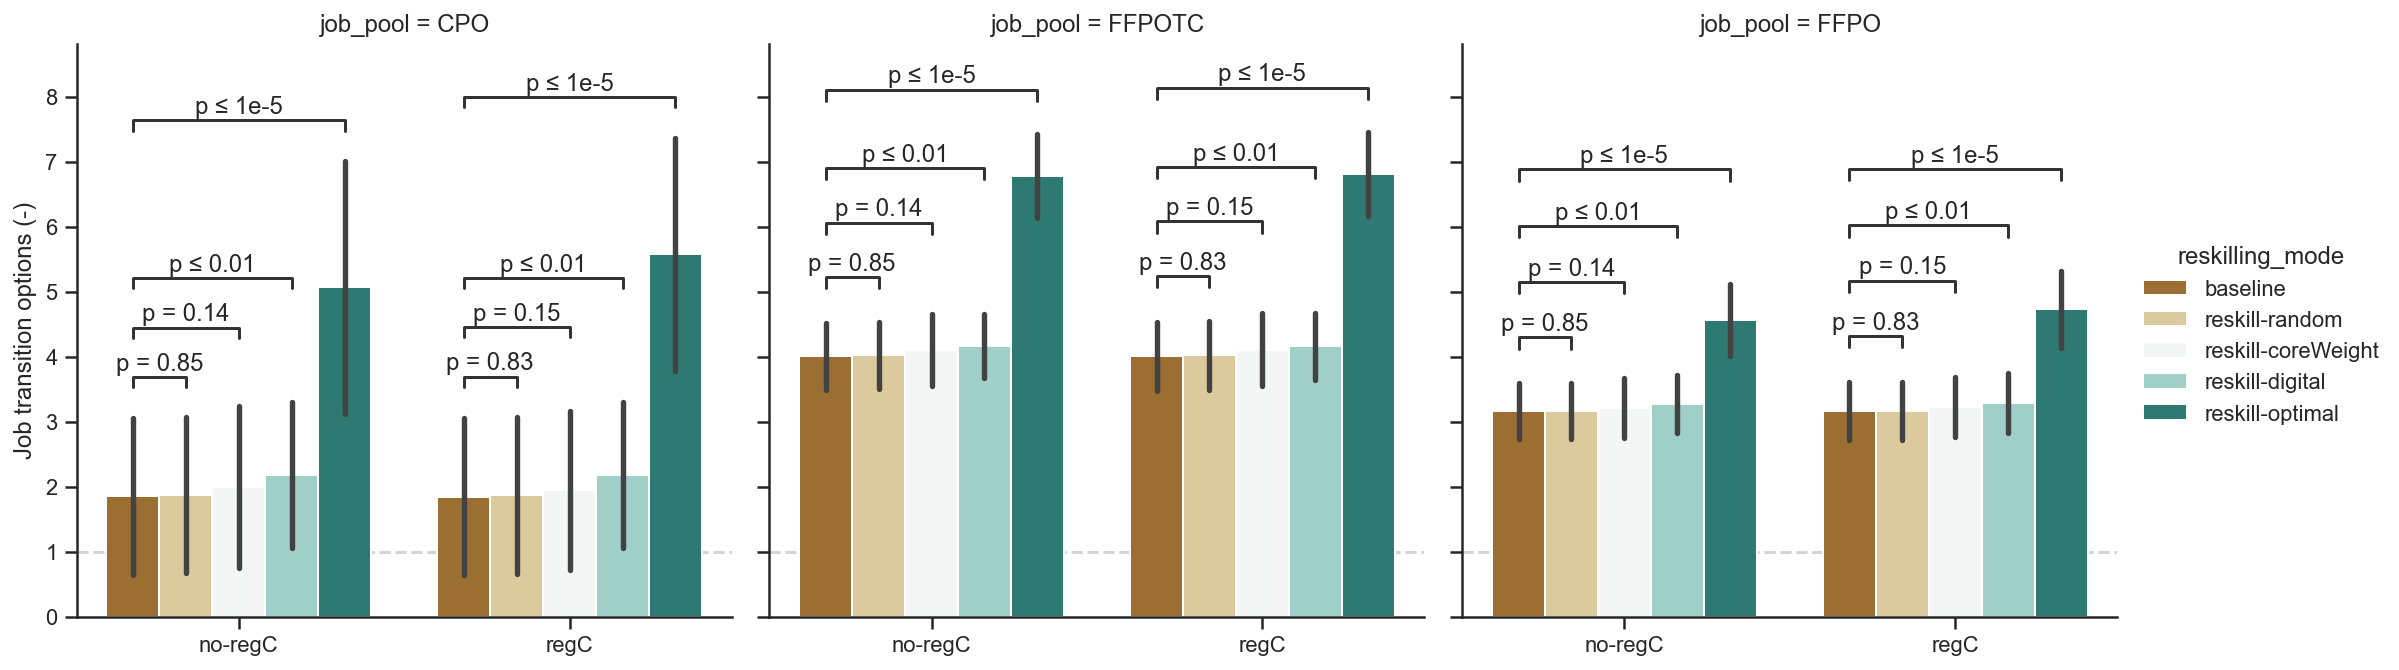

In [473]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind = "bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:

    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


Text(21.164475000000003, 0.5, 'Job transition options (-)')

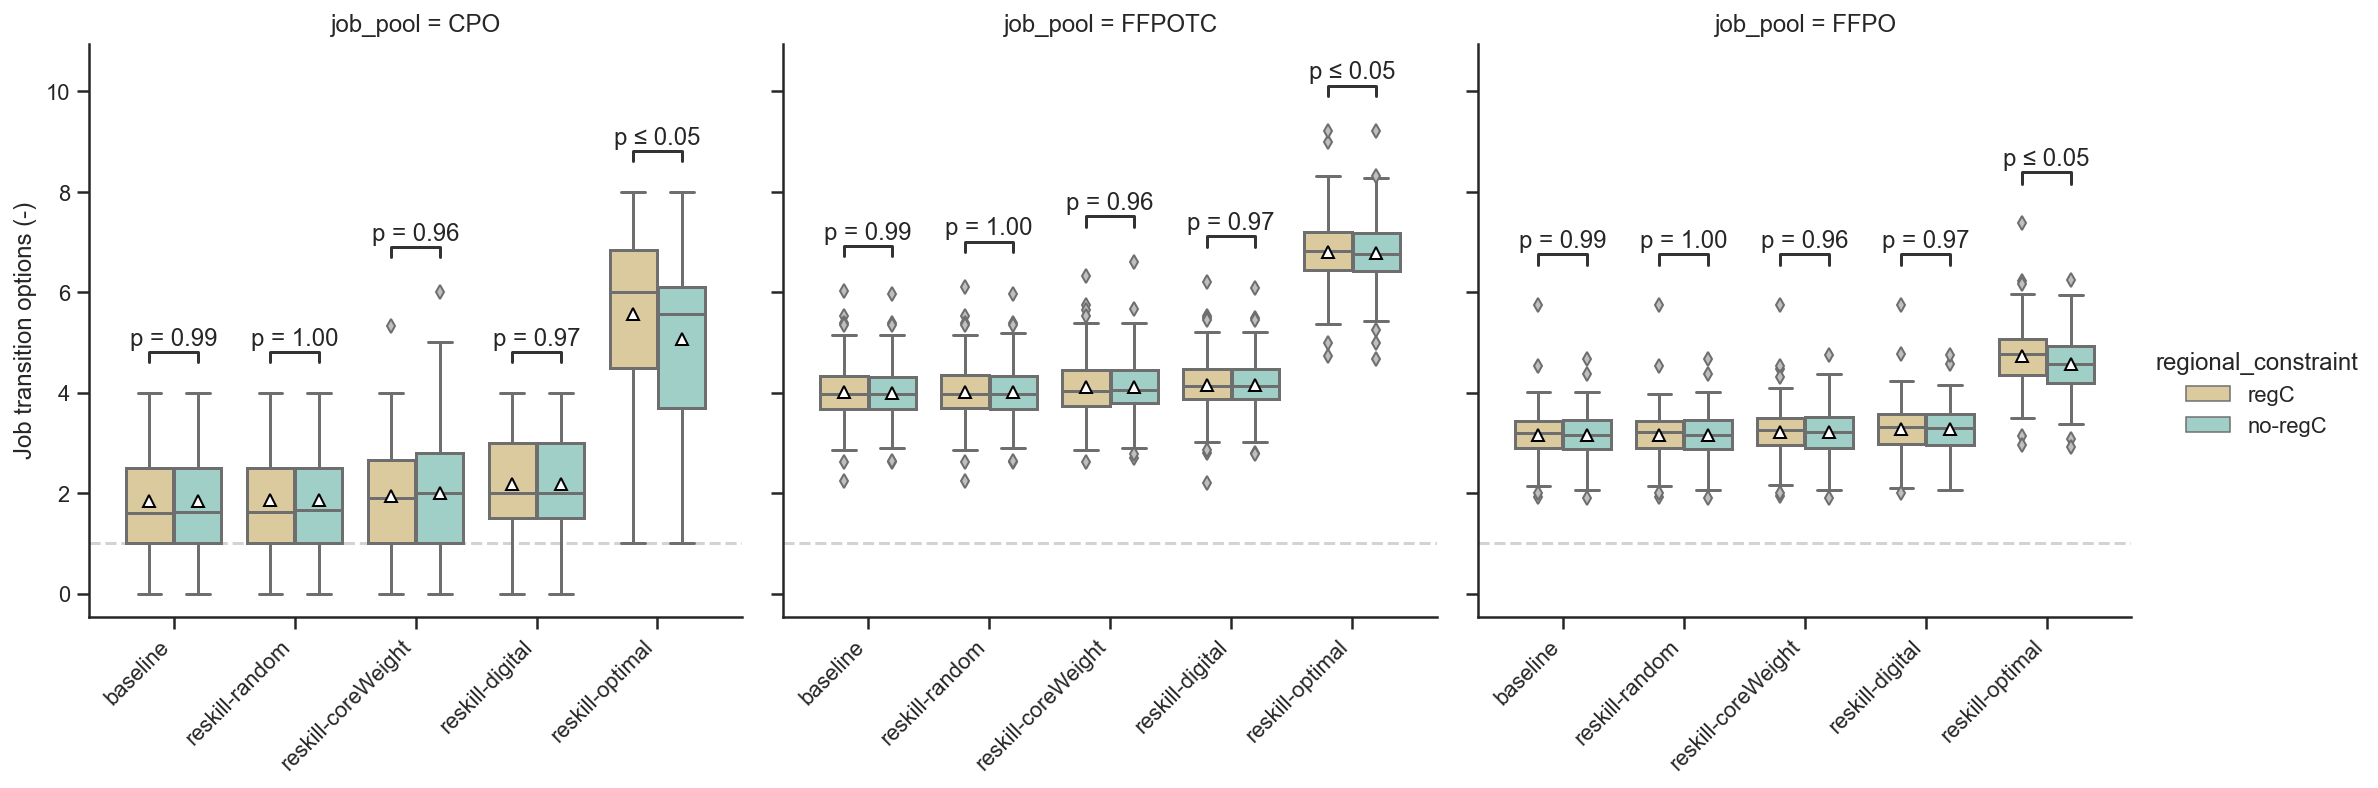

In [474]:
x = "reskilling_mode"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
# order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs_regional_hue, data=df_final, x=x, y=y, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


Hue = reskilling mode

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


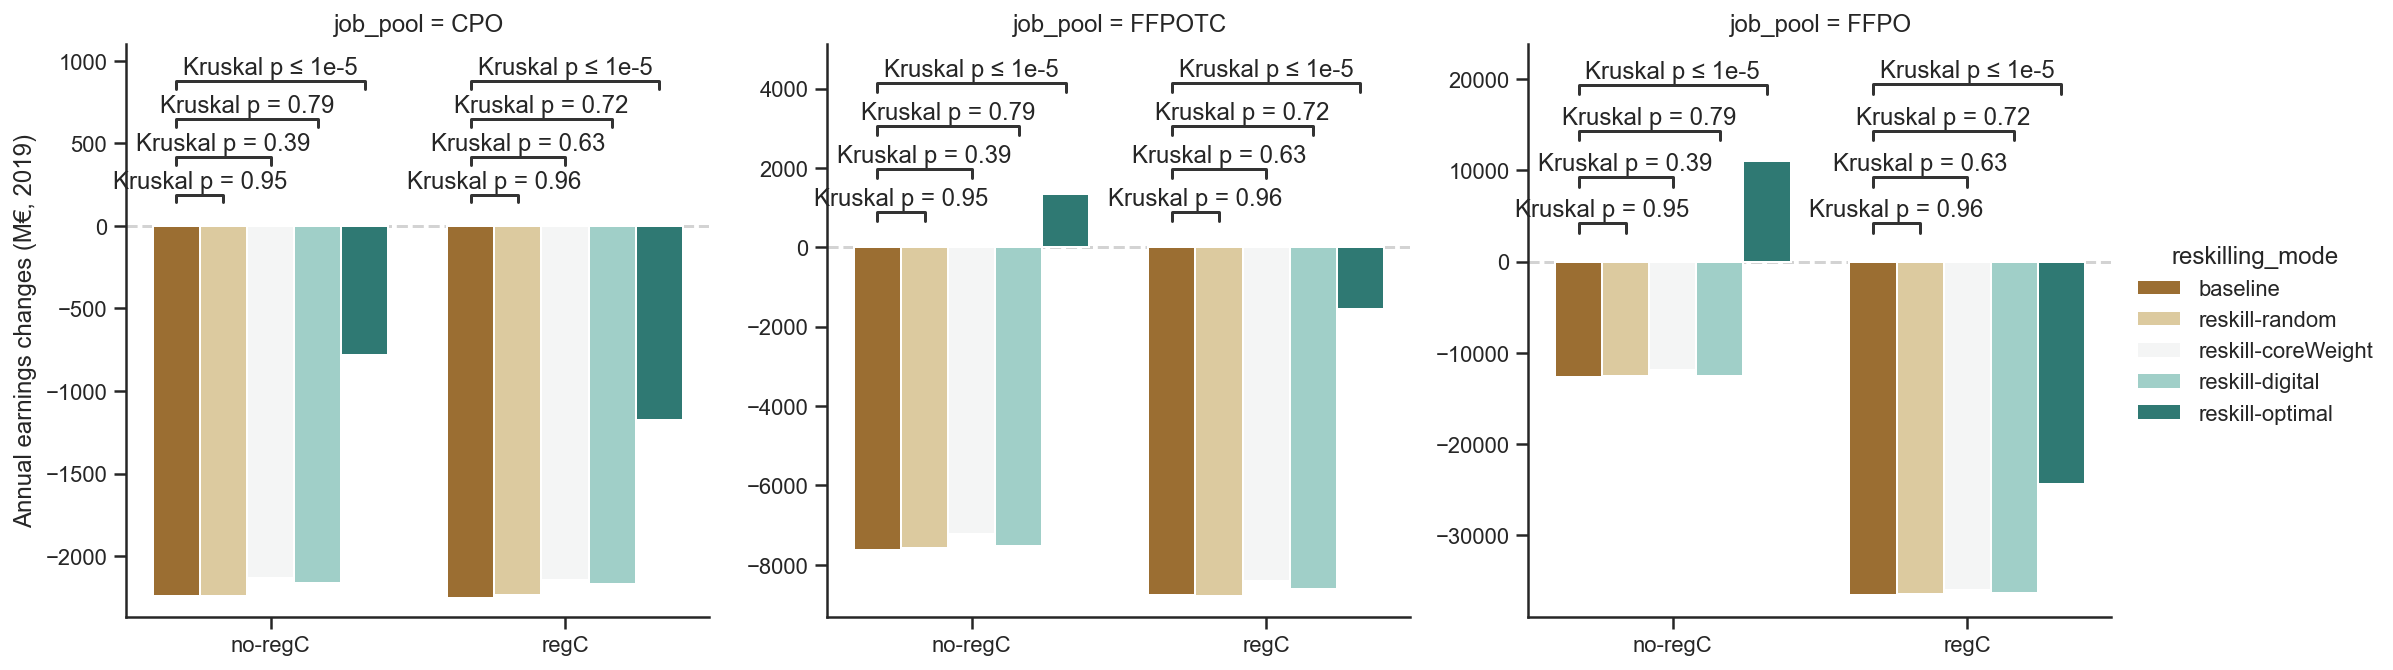

In [475]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=True,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


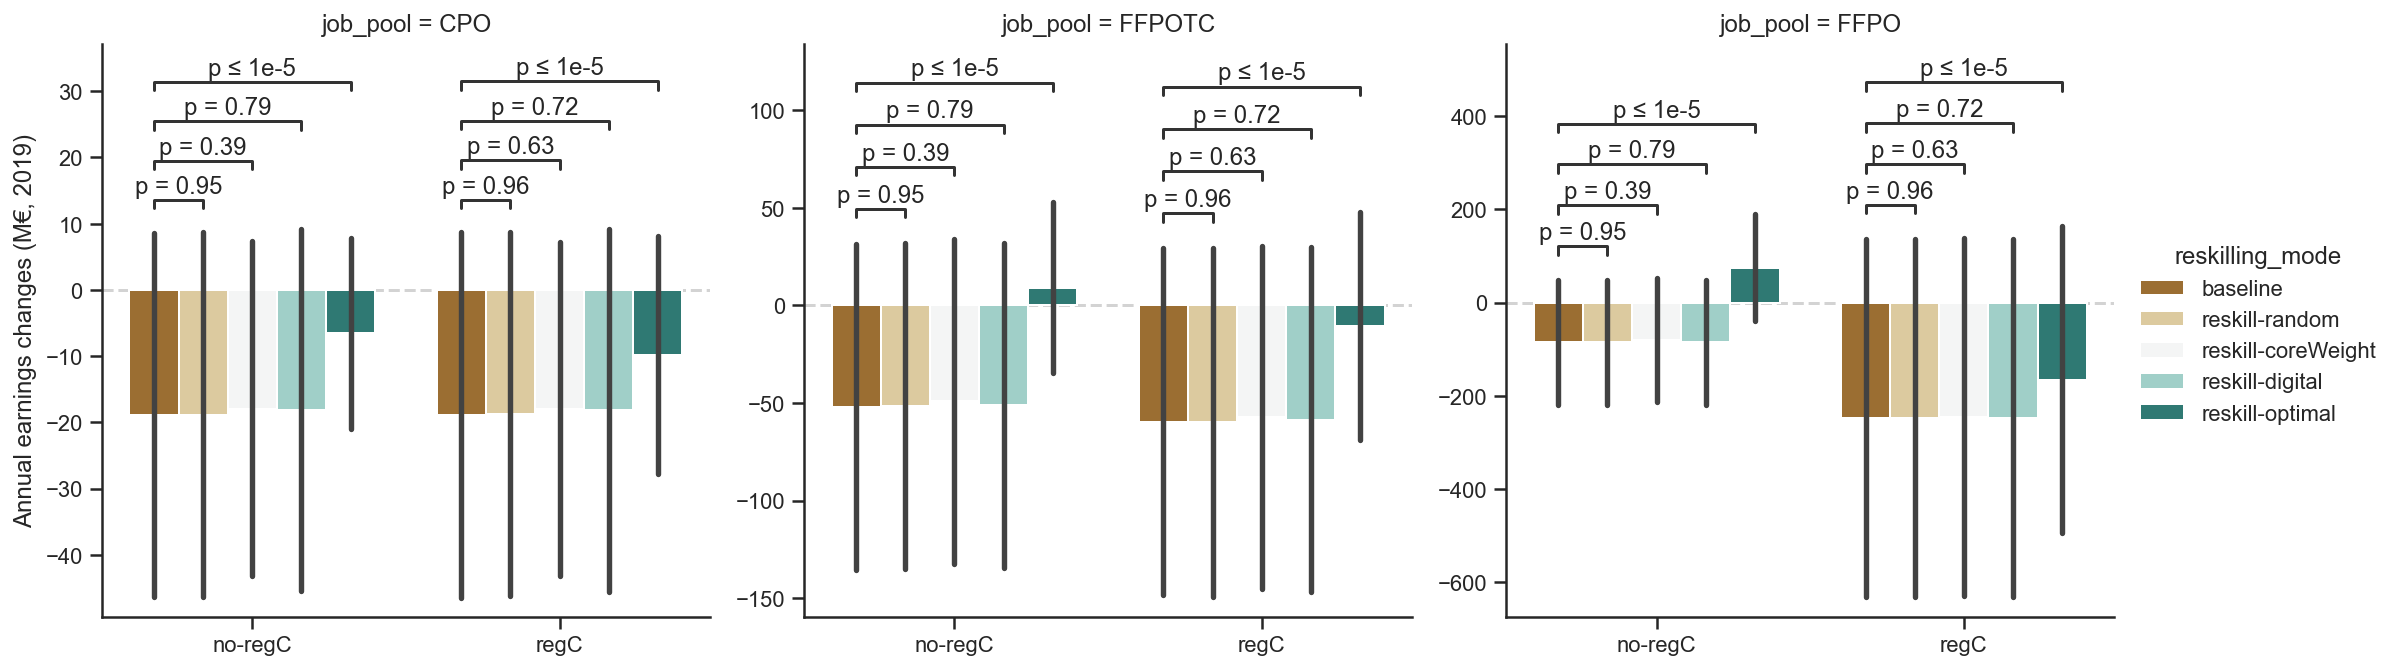

In [476]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


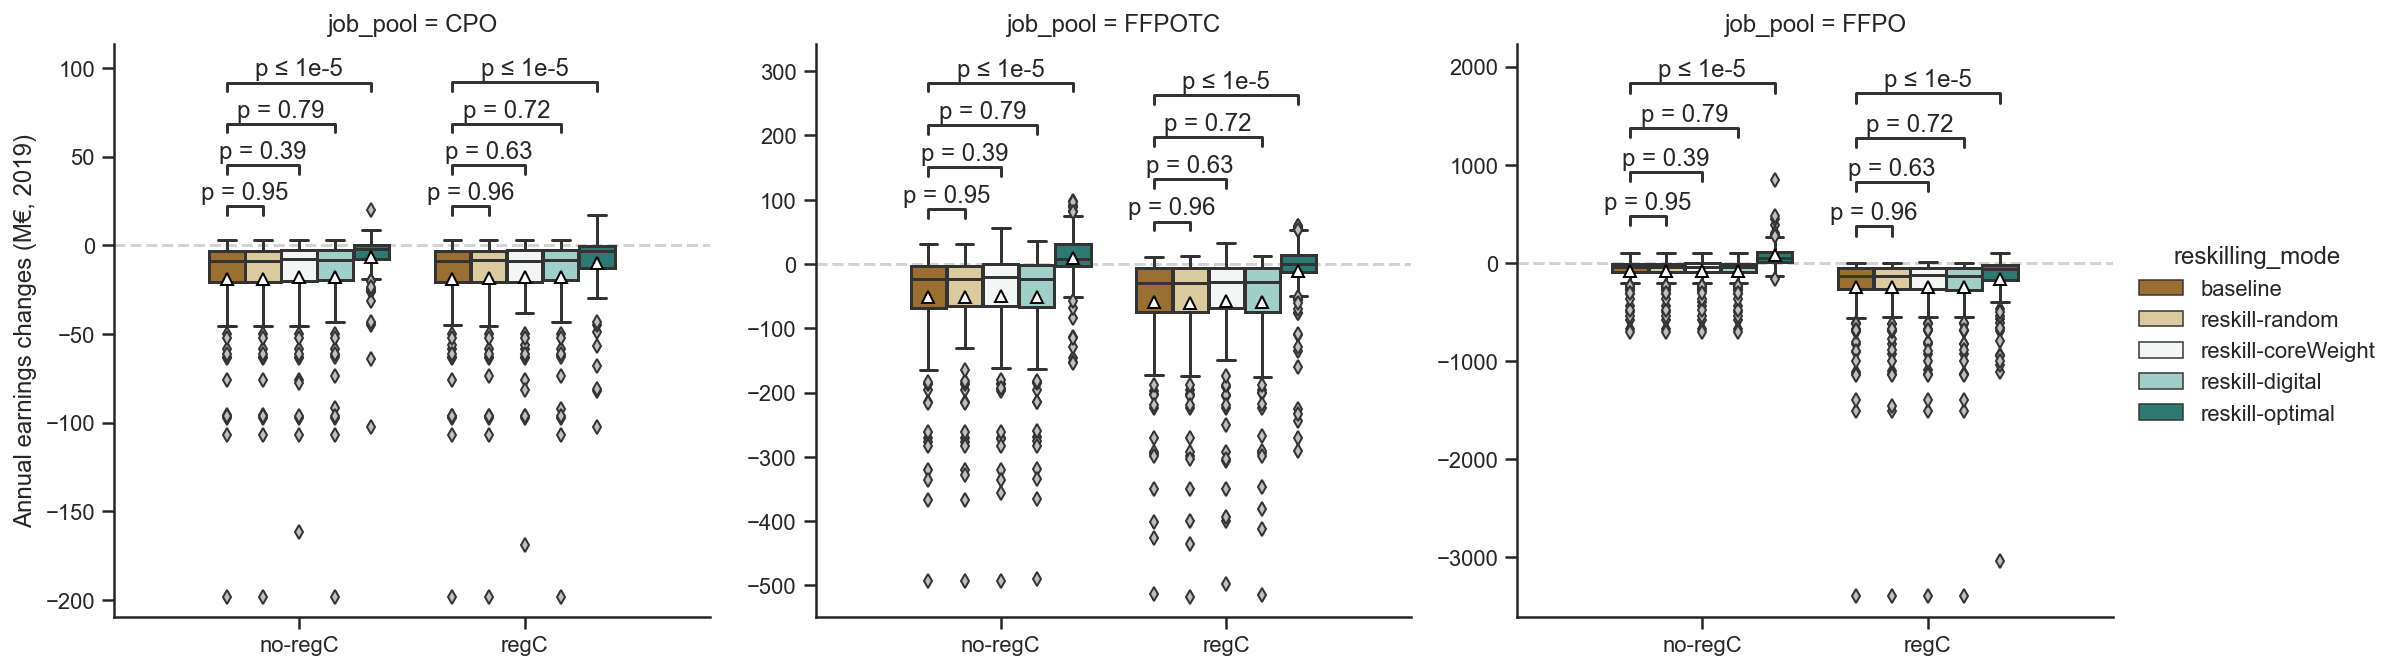

In [477]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_final,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_final, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

#### Results by country

In [478]:
df_final.groupby("COUNTRYW").describe()

n_viable_transitions                                     \
                        count mean  std  min  25%  50%  75%  max   
COUNTRYW                                                           
AT                     260.00 3.85 1.61 0.00 3.35 3.83 4.51 7.71   
BE                     280.00 3.86 1.29 1.00 3.12 3.61 4.04 8.00   
CH                     200.00 3.96 1.34 2.00 3.25 3.71 4.00 8.00   
CZ                     230.00 3.94 1.66 0.64 3.29 3.89 4.96 8.00   
DE                   1,120.00 3.43 1.36 0.00 2.59 3.25 3.91 8.00   
DK                     140.00 3.89 1.50 1.00 3.23 3.93 4.66 7.36   
ES                     489.00 3.67 1.52 0.00 3.00 3.66 4.35 7.45   
FI                     110.00 4.49 1.49 0.78 3.77 4.54 4.90 8.00   
FR                     670.00 3.80 1.54 0.00 3.00 3.65 4.39 9.00   
GR                     369.00 3.77 1.58 0.00 3.41 3.98 4.36 7.71   
HR                      60.00 3.93 1.36 2.00 3.17 4.00 4.19 8.00   
HU                     240.00 3.90 1.91 0.00 3.20 3.77 5.03 8.31   
IE                      90.00 3.18 1.61 0.38 1.62 3.41 4.09 6.91   
IS                      30.00 3.59 1.68 1.00 2.42 3.86 4.20 6.59   
IT                     598.00 3.52 1.58 0.00 2.77 3.53 4.24 8.00   
LT                      60.00 3.66 1.44 1.58 2.57 3.53 4.17 7.13   
NO                     199.00 3.08 1.64 0.00 2.82 3.28 3.89 6.61   
PT                     200.00 3.42 1.47 1.00 2.47 3.35 4.39 7.34   
RO                     240.00 3.55 1.91 0.02 2.36 3.48 4.78 9.21   
SE                     230.00 3.58 1.65 0.43 3.13 3.71 4.27 8.00   
SK                     120.00 3.84 1.58 1.42 2.99 4.00 4.75 7.65   
UK                     350.00 3.40 1.52 0.67 2.87 3.53 3.95 6.89   

         earnings_delta_closest_switch_sum_mio                           \
                                         count    mean    std       min   
COUNTRYW                                                                  
AT                                        0.00     NaN    NaN       NaN   
BE                                      280.00  -25.45  47.60   -266.62   
CH                                      200.00  -19.04  46.75   -168.57   
CZ                                        0.00     NaN    NaN       NaN   
DE                                    1,120.00 -131.62 222.16 -1,511.97   
DK                                      140.00  -40.00  69.87   -277.57   
ES                                        0.00     NaN    NaN       NaN   
FI                                      110.00   -6.95  52.10   -115.31   
FR                                      670.00  -66.92 113.41   -689.49   
GR                                        0.00     NaN    NaN       NaN   
HR                                       60.00   -0.54   3.20     -4.64   
HU                                      240.00  -10.27  28.11   -113.47   
IE                                       90.00  -54.15  89.59   -295.90   
IS                                        0.00     NaN    NaN       NaN   
IT                                      600.00 -102.81 357.12 -3,392.11   
LT                                       60.00  -17.57  26.09    -86.39   
NO                                        0.00     NaN    NaN       NaN   
PT                                      200.00  -19.21  59.26   -329.74   
RO                                      240.00  -21.28  32.40   -132.10   
SE                                        0.00     NaN    NaN       NaN   
SK                                      120.00  -33.04  64.59   -324.15   
UK                                        0.00     NaN    NaN       NaN   

                                       
             25%    50%    75%    max  
COUNTRYW                               
AT           NaN    NaN    NaN    NaN  
BE        -31.25  -9.29  -2.34 121.89  
CH        -32.16  -5.58  -1.80 179.32  
CZ           NaN    NaN    NaN    NaN  
DE       -164.97 -53.97 -11.26 380.87  
DK        -57.19 -10.80  -3.70 111.38  
ES           NaN    NaN    NaN    NaN  
FI        -41.61  -3.64   3.87 2

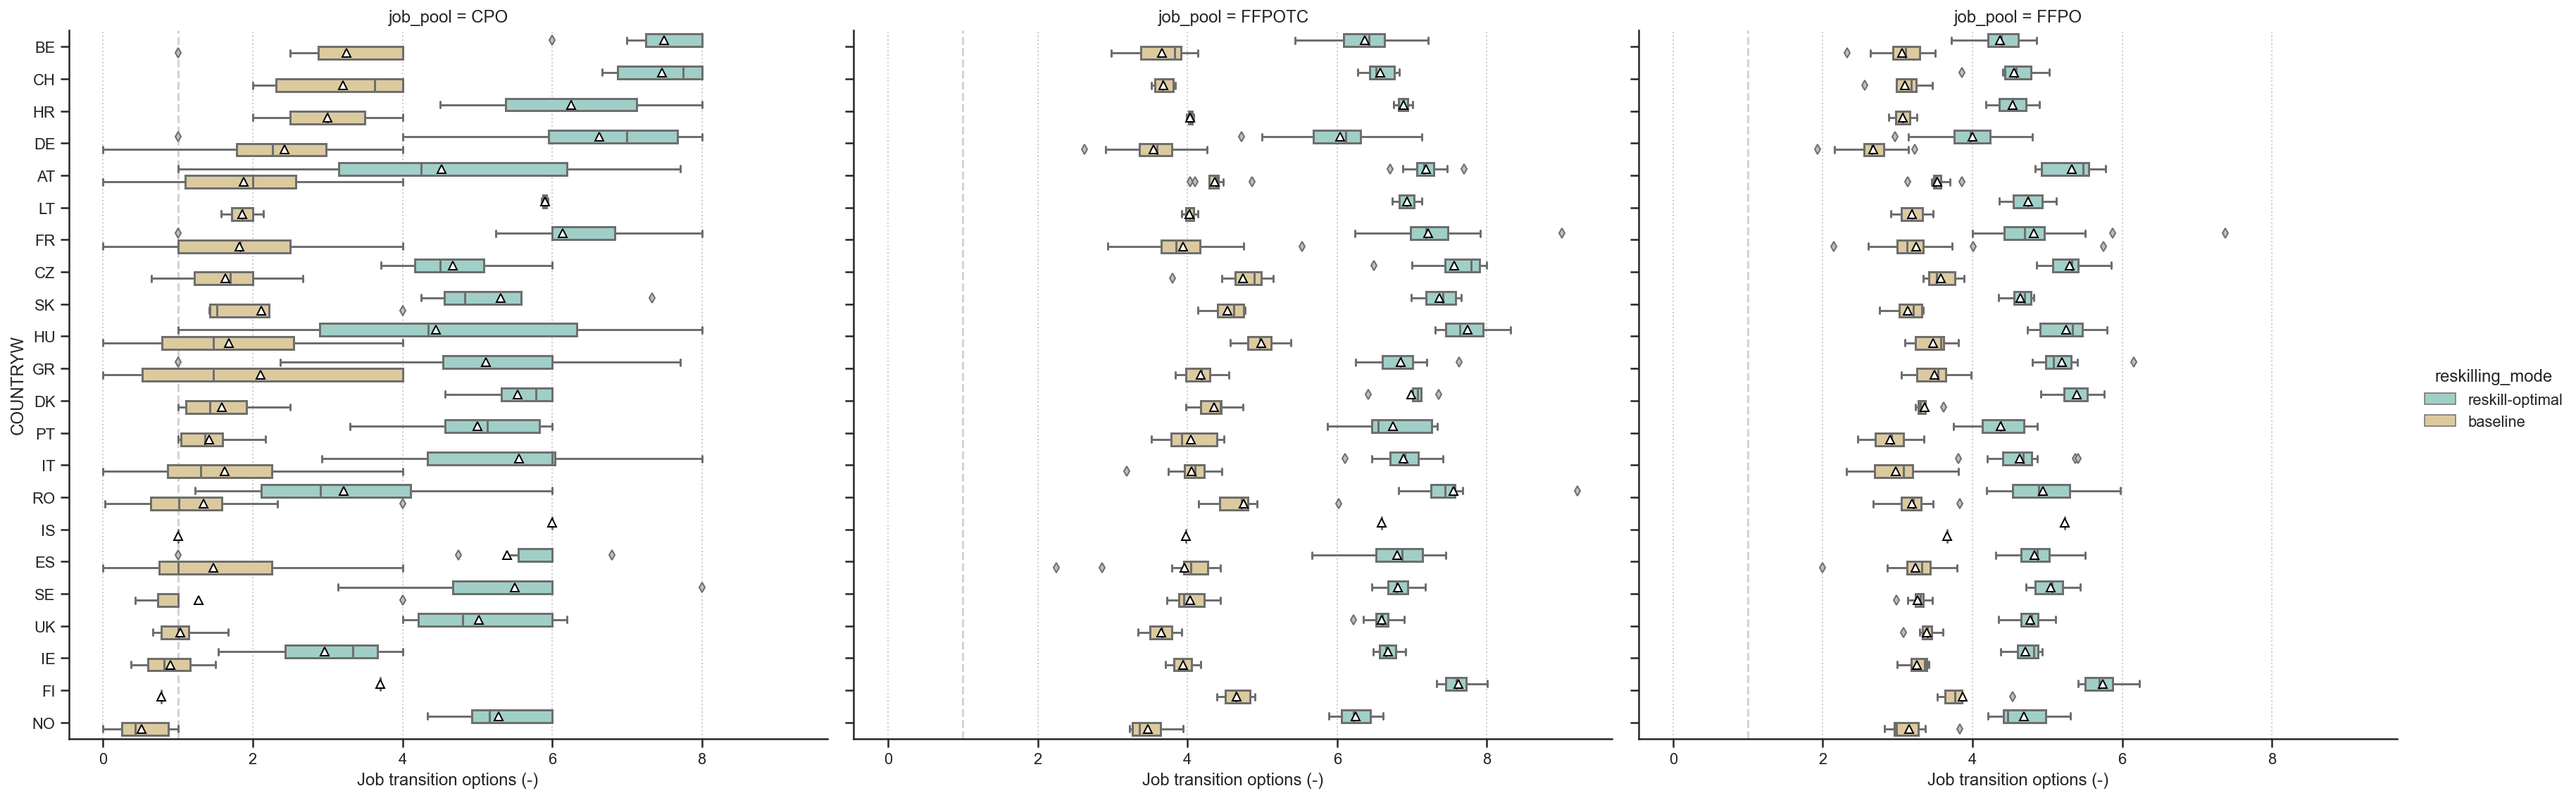

In [479]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "box"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_final.loc[
    (df_final["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_final["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_final["reskilling_mode"].isin(["baseline"])
            & (df_final["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for ax in axes:
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

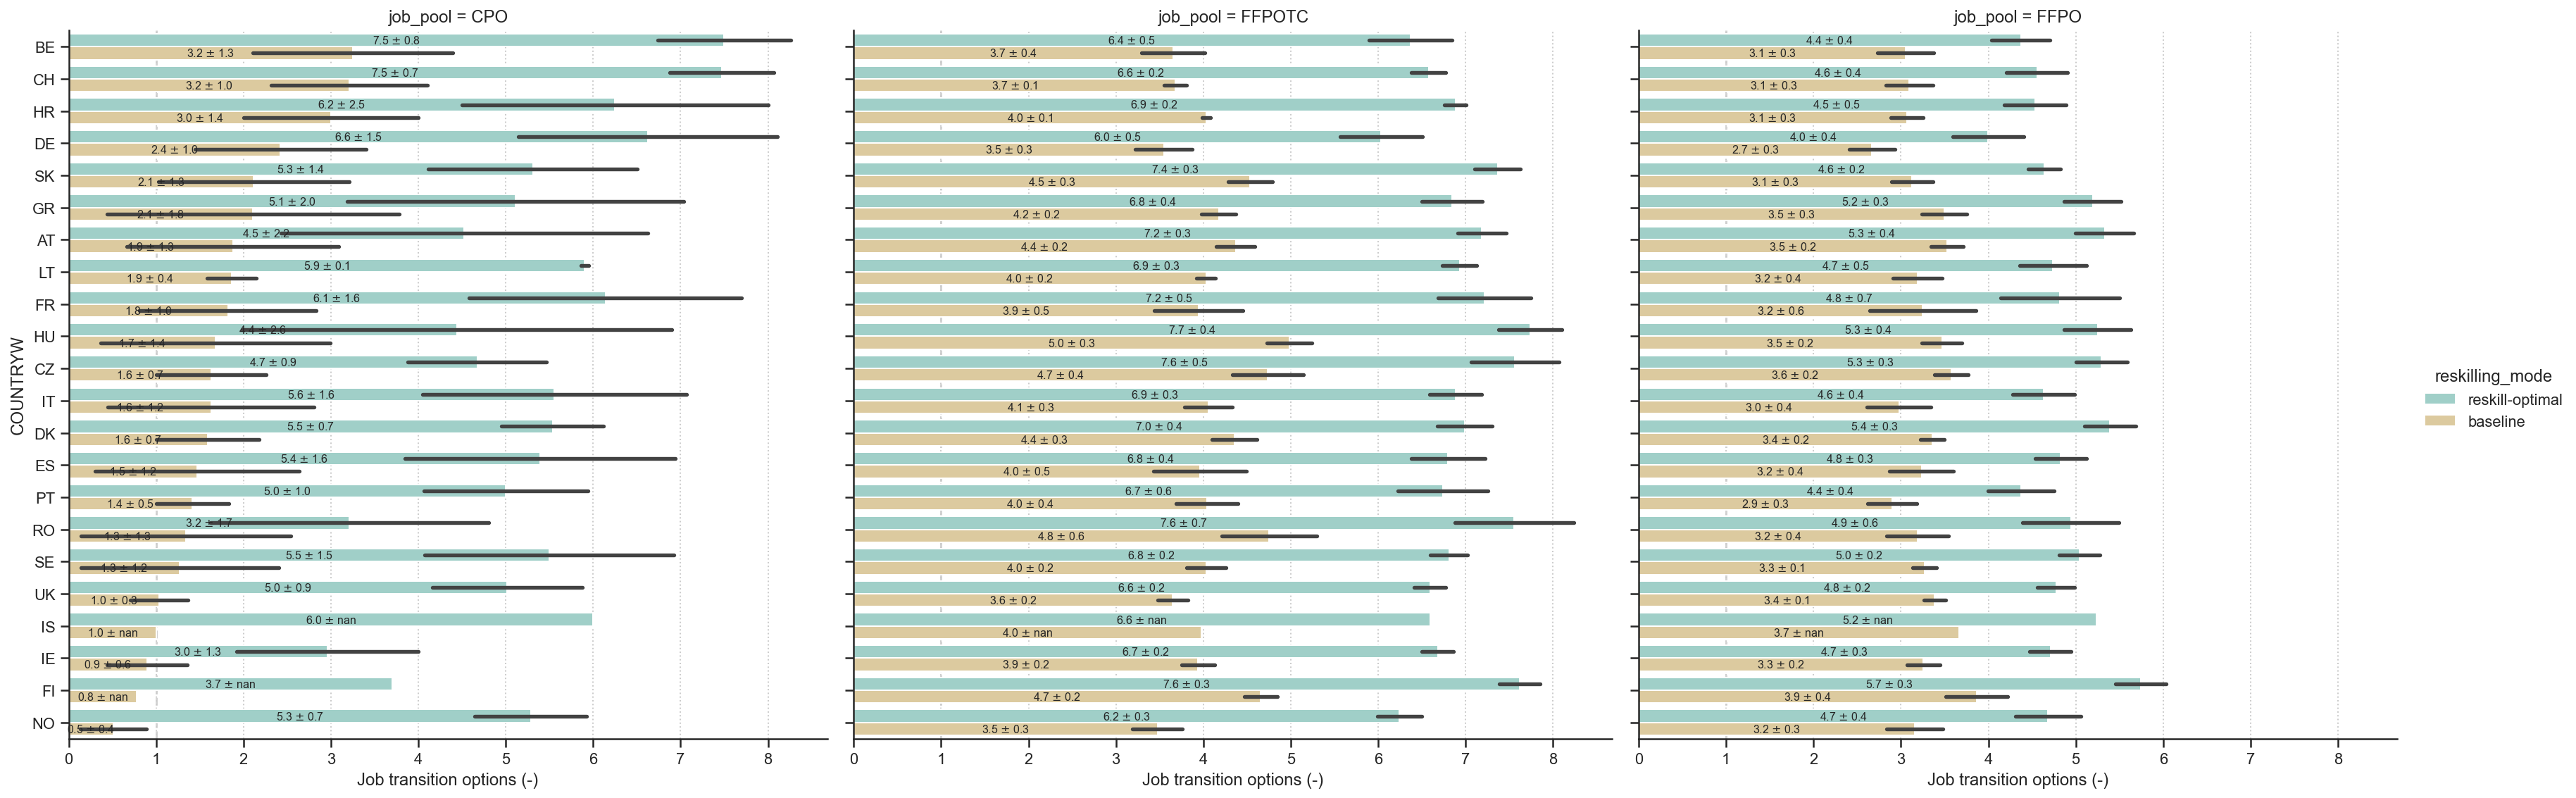

In [483]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "bar"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_final.loc[
    (df_final["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_final["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_final["reskilling_mode"].isin(["baseline"])
            & (df_final["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    ci="sd",
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

aggdict = {
    "n_viable_transitions": [np.mean, np.std],
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}
df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot.columns = ["_".join(col) for col in df_annot.columns]
df_annot = df_annot.reindex(order, level=1).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        labels = (
            df_hue.loc[:, "n_viable_transitions_mean"].round(1).astype(str)
            + r" $\pm$ "
            + df_hue.loc[:, "n_viable_transitions_std"].round(1).astype(str)
        )
        ax.bar_label(container, labels=labels, fontsize=8, label_type="center")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [481]:
df_annot

,job_pool,COUNTRYW,reskilling_mode,n_viable_transitions_mean,n_viable_transitions_std,earnings_delta_closest_switch_sum_mio_mean,viability_threshold_first
0,CPO,BE,baseline,3.25,1.25,-3.58,low
1,CPO,BE,reskill-optimal,7.50,0.84,-2.07,low
2,CPO,CH,baseline,3.21,0.98,-6.40,low
3,CPO,CH,reskill-optimal,7.47,0.65,-3.49,low
4,CPO,HR,baseline,3.00,1.41,-1.74,low
...,...,...,...,...,...,...,...
127,FFPOTC,IE,reskill-optimal,6.68,0.22,11.73,low
128,FFPOTC,FI,baseline,4.66,0.21,-5.59,low
129,FFPOTC,FI,reskill-optimal,7.62,0.26,42.71,low
130,FFPOTC,NO,baseline,3.47,0.31,NaN,low


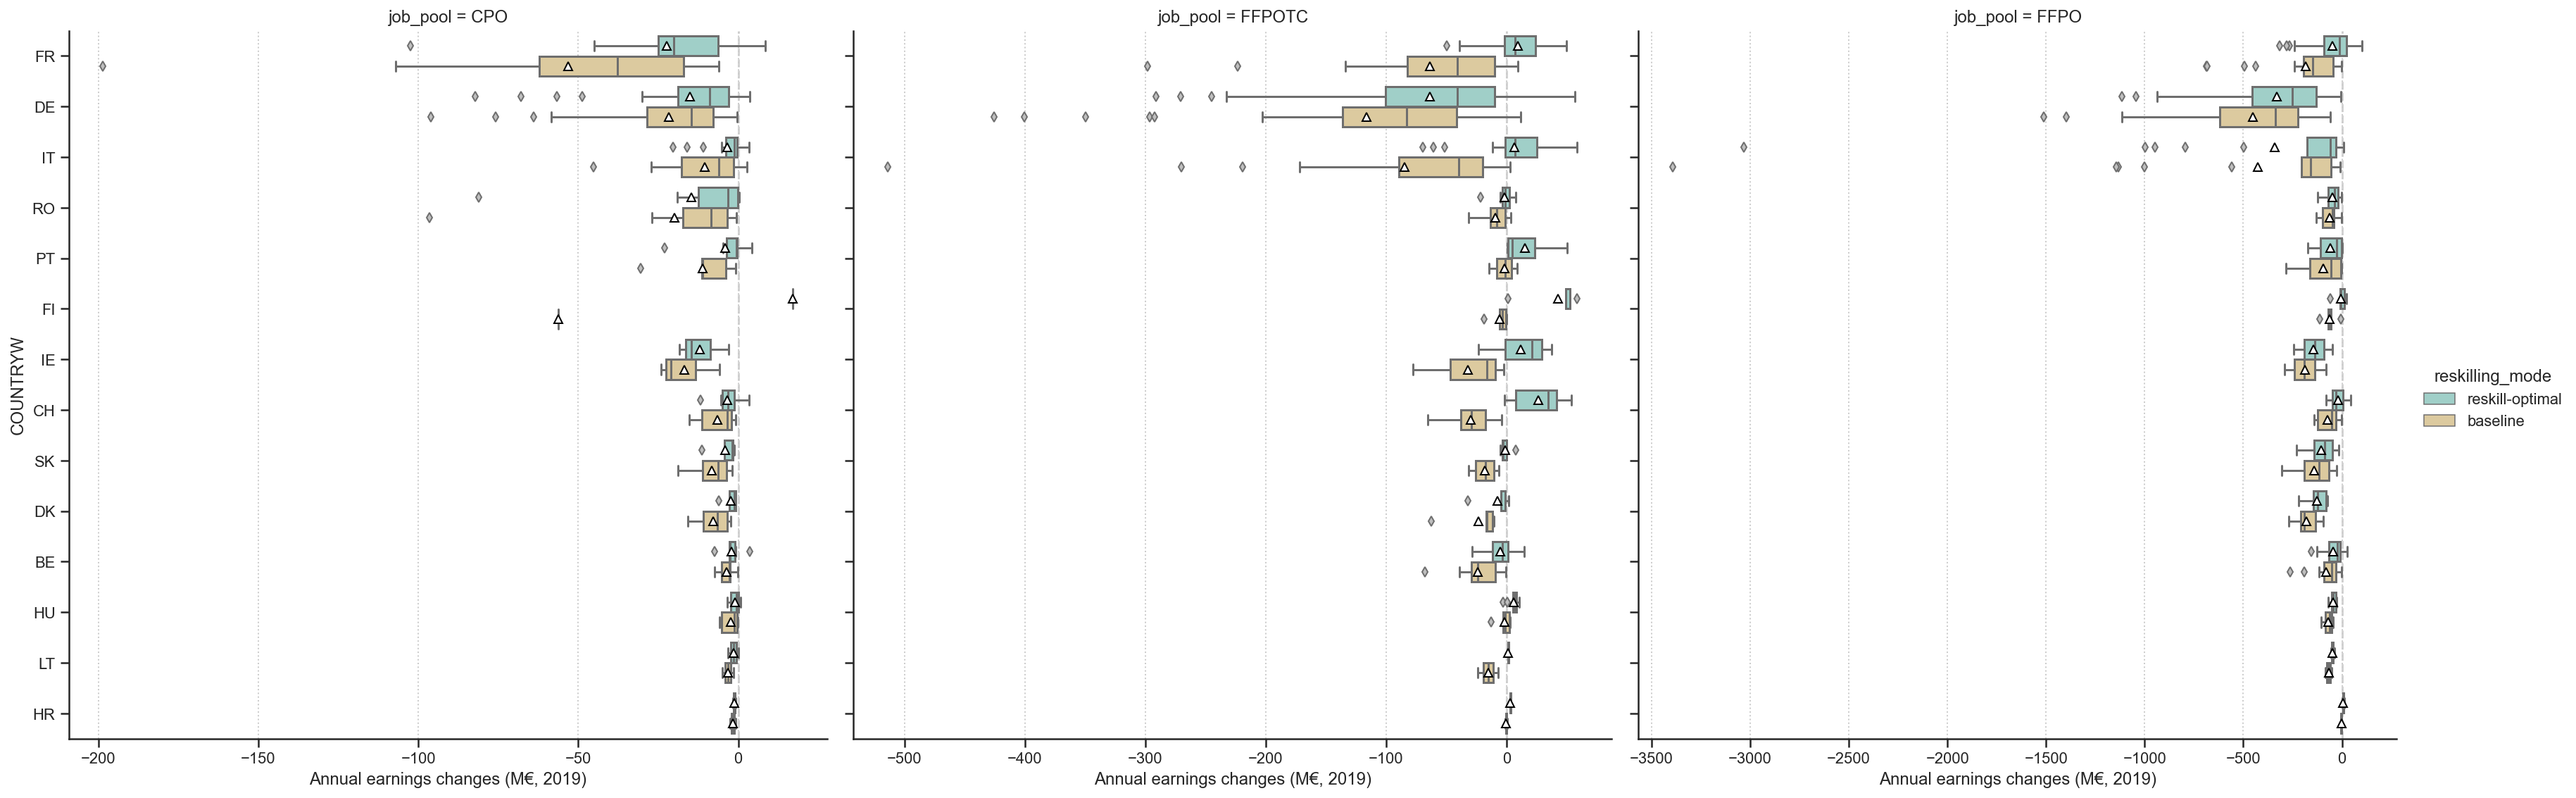

In [484]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "box"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df = df_final.loc[
    (df_final["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_final["regional_constraint"] == "regC")
    & (~df_final["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_final["reskilling_mode"].isin(["baseline"])
            & (df_final["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

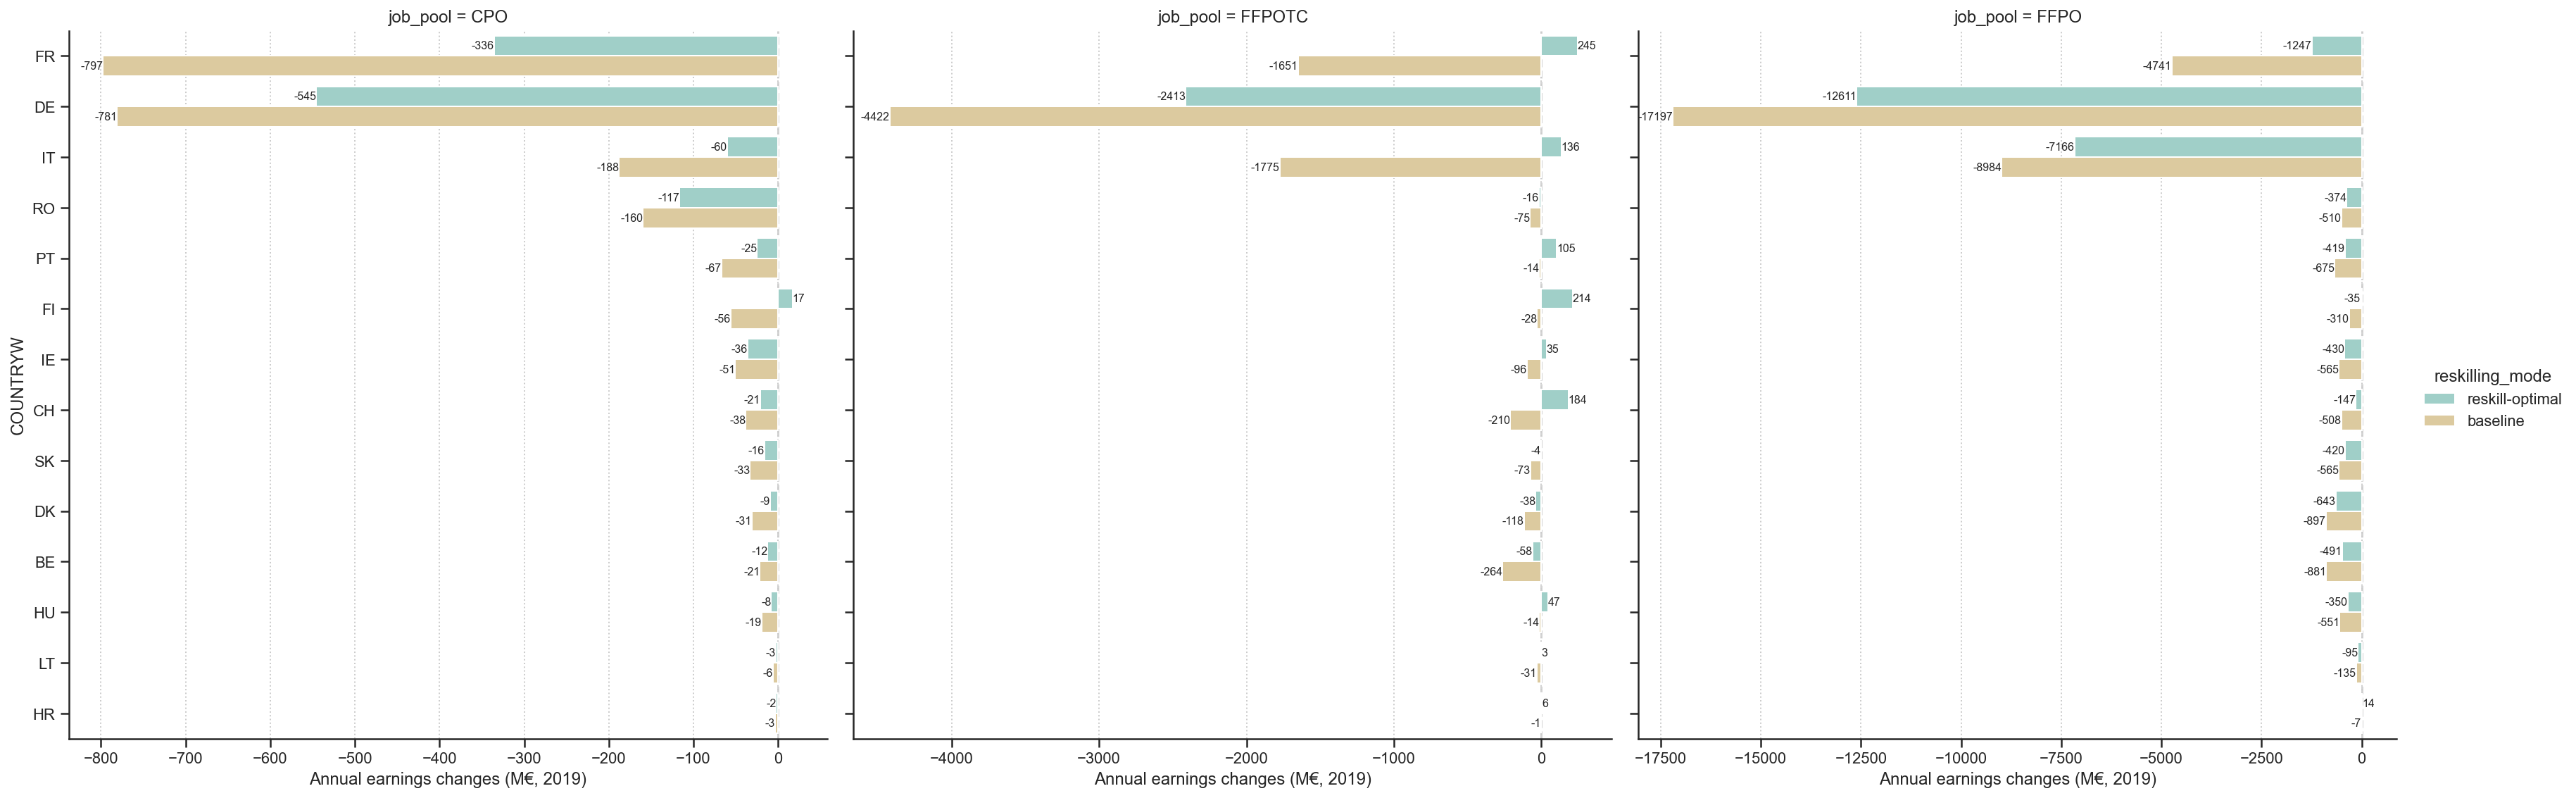

In [485]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "bar"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

# calc order
df = df_final.loc[
    (df_final["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_final["regional_constraint"] == "regC")
    & (~df_final["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_final["reskilling_mode"].isin(["baseline"])
            & (df_final["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci=False,
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot = df_annot.reindex(order, level=0).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")
    ax.grid(linestyle=":", axis="x")

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        ax.bar_label(
            container, labels=df_annot[x], fmt="%.0f", fontsize=8, label_type="edge"
        )

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)